In [1]:
import kagglehub

path = kagglehub.dataset_download(
    "gunavenkatdoddi/eye-diseases-classification"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Path to dataset files: /kaggle/input/eye-diseases-classification


In [2]:
DATASET_PATH = "/kaggle/input/eye-diseases-classification/dataset"

In [3]:
!ls "$DATASET_PATH"

cataract  diabetic_retinopathy	glaucoma  normal


In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_CLASSES = 4

In [6]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return enhanced

In [7]:
def segment_blood_vessels(img):
    green = img[:, :, 1]
    blurred = cv2.GaussianBlur(green, (5,5), 0)

    _, vessel_mask = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    vessel_mask = cv2.morphologyEx(vessel_mask, cv2.MORPH_OPEN, kernel)

    return vessel_mask

In [8]:
def segment_optic_disc(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.medianBlur(gray, 5)

    mask = np.zeros_like(gray)

    circles = cv2.HoughCircles(
        gray,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=100,
        param1=50,
        param2=30,
        minRadius=30,
        maxRadius=120
    )

    if circles is not None:
        circles = np.uint16(np.around(circles))
        x, y, r = circles[0][0]
        cv2.circle(mask, (x, y), r, 255, -1)

    return mask

In [9]:
def segment_exudates(img, optic_disc_mask):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray[optic_disc_mask == 255] = 0

    _, exudate_mask = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    exudate_mask = cv2.morphologyEx(exudate_mask, cv2.MORPH_OPEN, kernel)

    return exudate_mask


In [10]:
def combine_segments(img, vessels, optic_disc, exudates):
    combined = np.zeros_like(img)

    combined[vessels == 255] = img[vessels == 255]
    combined[optic_disc == 255] = img[optic_disc == 255]
    combined[exudates == 255] = img[exudates == 255]

    return combined


In [11]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    enhanced = apply_clahe(img)
    vessels = segment_blood_vessels(enhanced)
    optic_disc = segment_optic_disc(enhanced)
    exudates = segment_exudates(enhanced, optic_disc)

    final_img = combine_segments(enhanced, vessels, optic_disc, exudates)


    final_img = preprocess_input(final_img)

    return final_img

In [12]:
class RetinalDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size=8, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_x = self.image_paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_y = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        X, y = [], []

        for path, label in zip(batch_x, batch_y):
            img = preprocess_image(path)

            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)

            X.append(img)
            y.append(label)

        return np.array(X), np.array(y)

In [13]:
class_names = [
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "normal"
]

label_map = {cls: idx for idx, cls in enumerate(class_names)}

image_paths = []
labels = []

for cls in class_names:
    folder = os.path.join(DATASET_PATH, cls)
    for img in os.listdir(folder):
        image_paths.append(os.path.join(folder, img))
        labels.append(label_map[cls])

labels = np.array(labels)

In [14]:
train_p, temp_p, train_l, temp_l = train_test_split(
    image_paths,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

val_p, test_p, val_l, test_l = train_test_split(
    temp_p,
    temp_l,
    test_size=0.5,
    random_state=42,
    stratify=temp_l
)

train_l = to_categorical(train_l, NUM_CLASSES)
val_l   = to_categorical(val_l, NUM_CLASSES)
test_l  = to_categorical(test_l, NUM_CLASSES)

train_gen = RetinalDataGenerator(train_p, train_l, BATCH_SIZE, augment=True)
val_gen   = RetinalDataGenerator(val_p, val_l, BATCH_SIZE)
test_gen  = RetinalDataGenerator(test_p, test_l, BATCH_SIZE)


In [15]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze most layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Unfreeze last layers
for layer in base_model.layers[-40:]:
    layer.trainable = True


# Custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 1,091,140 (4.16 MB)

 Non-trainable params: 6,209,792 (23.69 MB)

In [16]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 203s 443ms/step - accuracy: 0.6855 - loss: 0.7912 - val_accuracy: 0.8829 - val_loss: 0.3416
Epoch 2/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 125s 340ms/step - accuracy: 0.8370 - loss: 0.4618 - val_accuracy: 0.8924 - val_loss: 0.2683
Epoch 3/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 123s 335ms/step - accuracy: 0.8835 - loss: 0.3392 - val_accuracy: 0.9082 - val_loss: 0.2312
Epoch 4/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 124s 337ms/step - accuracy: 0.9025 - loss: 0.2631 - val_accuracy: 0.9019 - val_loss: 0.2449
Epoch 5/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 124s 337ms/step - accuracy: 0.9253 - loss: 0.2091 - val_accuracy: 0.9241 - val_loss: 0.2355
Epoch 6/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 125s 338ms/step - accuracy: 0.9603 - loss: 0.1296 - val_accuracy: 0.9098 - val_loss: 0.2337
Epoch 7/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 125s 338ms/step - accuracy: 0.9732 - loss: 0.0837 - val_accuracy: 0.9130 - val_loss: 0.2652
Epoch 8/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 124s 337ms/step - accuracy: 0.9810 -

In [17]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 371ms/step - accuracy: 0.9383 - loss: 0.2206
Test Accuracy: 0.9382911324501038


79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 290ms/step
Prediction length: 632
True length: 632


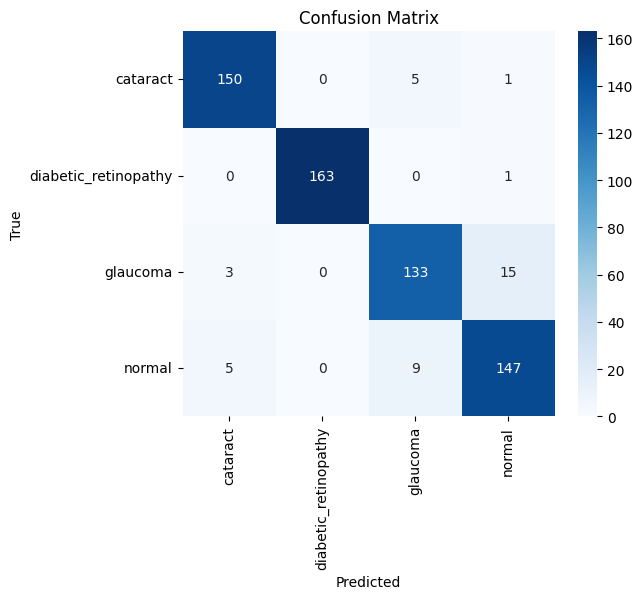


Classification Report:

                      precision    recall  f1-score   support

            cataract     0.9494    0.9615    0.9554       156
diabetic_retinopathy     1.0000    0.9939    0.9969       164
            glaucoma     0.9048    0.8808    0.8926       151
              normal     0.8963    0.9130    0.9046       161

            accuracy                         0.9383       632
           macro avg     0.9376    0.9373    0.9374       632
        weighted avg     0.9383    0.9383    0.9382       632



In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true_full = np.argmax(test_l, axis=1)


y_true = y_true_full[:len(y_pred)]

print("Prediction length:", len(y_pred))
print("True length:", len(y_true))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)